In [ ]:
!pip install --upgrade --no-cache-dir gdown
!gdown 1SZZrpCgW8fI85m-_RpCygNuapWH3l0Vj

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2
Downloading...
From (original): https://drive.google.com/uc?id=1SZZrpCgW8fI85m-_RpCygNuapWH3l0Vj
From (redirected): https://drive.google.com/uc?id=1SZZrpCgW8fI85m-_RpCygNuapWH3l0Vj&confirm=t&uuid=c69df1b6-11c3-4d63-b9e7-3cf13aec9da8
To: /content/archive.zip
100% 27.6M/27.6M [00:01<00:00, 22.0MB/s]


#1) Setup

In [ ]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.3 MB/s eta 0:00:00


In [ ]:
import os
import shutil
import random
import xml.etree.ElementTree as ET
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

#2) Upload Dataset

In [ ]:
!unzip -q archive.zip -d /content/dataset

In [ ]:
!find /content/dataset -maxdepth 3 -type d

/content/dataset
/content/dataset/NEU-DET
/content/dataset/NEU-DET/IMAGES
/content/dataset/NEU-DET/ANNOTATIONS


#3) Paths

In [ ]:
ROOT = Path("/content/dataset/NEU-DET")
IMG_DIR = ROOT / "IMAGES"
ANN_DIR = ROOT / "ANNOTATIONS"

print("Images:", len(list(IMG_DIR.glob("*.jpg"))))
print("Annotations:", len(list(ANN_DIR.glob("*.xml"))))

Images: 1800
Annotations: 1800


#4) Reading XML and displaying Bounding Box

In [ ]:
def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text.strip()

    # Some XML files have filenames without extension
    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        filename = filename + ".jpg"

    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    objects = []

    for obj in root.findall("object"):
        label = obj.find("name").text.strip()
        bbox = obj.find("bndbox")

        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        objects.append({
            "label": label,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return filename, width, height, objects

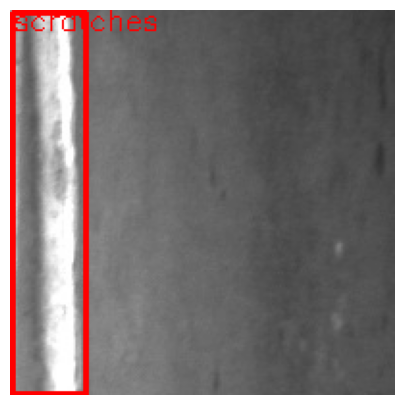

In [ ]:
sample_xml = list(ANN_DIR.glob("*.xml"))[0]
filename, width, height, objects = parse_voc_xml(sample_xml)

img_path = IMG_DIR / filename
img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

for obj in objects:
    xmin, ymin, xmax, ymax = obj["bbox"]
    label = obj["label"]
    cv2.rectangle(img_rgb, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
    cv2.putText(img_rgb, label, (xmin, max(ymin - 5, 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

#5) Classes

In [ ]:
classes = set()

for xml_path in ANN_DIR.glob("*.xml"):
    _, _, _, objects = parse_voc_xml(xml_path)
    for obj in objects:
        classes.add(obj["label"])

classes = sorted(list(classes))
class_to_id = {cls: i for i, cls in enumerate(classes)}

print(classes)
print(class_to_id)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']
{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled-in_scale': 4, 'scratches': 5}


#6) Convert XML to YOLO format

In [ ]:
YOLO_ROOT = Path("/content/neu_yolo")
for split in ["train", "val", "test"]:
    (YOLO_ROOT / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_ROOT / "labels" / split).mkdir(parents=True, exist_ok=True)

In [ ]:
xml_files = list(ANN_DIR.glob("*.xml"))
random.seed(42)
random.shuffle(xml_files)

n = len(xml_files)
train_files = xml_files[:int(0.7*n)]
val_files = xml_files[int(0.7*n):int(0.85*n)]
test_files = xml_files[int(0.85*n):]

splits = {
    "train": train_files,
    "val": val_files,
    "test": test_files
}

print(len(train_files), len(val_files), len(test_files))

1260 270 270


In [ ]:
def voc_to_yolo_bbox(bbox, img_w, img_h):
    xmin, ymin, xmax, ymax = bbox

    x_center = ((xmin + xmax) / 2) / img_w
    y_center = ((ymin + ymax) / 2) / img_h
    box_w = (xmax - xmin) / img_w
    box_h = (ymax - ymin) / img_h

    return x_center, y_center, box_w, box_h

In [ ]:
for split, files in splits.items():
    for xml_path in files:
        filename, width, height, objects = parse_voc_xml(xml_path)

        src_img = IMG_DIR / filename
        dst_img = YOLO_ROOT / "images" / split / filename
        shutil.copy(src_img, dst_img)

        label_filename = Path(filename).stem + ".txt"
        dst_label = YOLO_ROOT / "labels" / split / label_filename

        with open(dst_label, "w") as f:
            for obj in objects:
                class_id = class_to_id[obj["label"]]
                x, y, w, h = voc_to_yolo_bbox(obj["bbox"], width, height)
                f.write(f"{class_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

#7) Creating a YAML file for YOLOv8

In [ ]:
yaml_content = f"""
path: {YOLO_ROOT}
train: images/train
val: images/val
test: images/test

names:
"""

for i, cls in enumerate(classes):
    yaml_content += f"  {i}: {cls}\n"

yaml_path = YOLO_ROOT / "neu_det.yaml"

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(yaml_content)


path: /content/neu_yolo
train: images/train
val: images/val
test: images/test

names:
  0: crazing
  1: inclusion
  2: patches
  3: pitted_surface
  4: rolled-in_scale
  5: scratches



#8) YOLOv8n training

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=200,
    batch=16,
    patience=10,
    project="/content/runs",
    name="neu_yolov8n"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/neu_yolo/neu_det.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, 

#9) Evaluation on the test

In [ ]:
model = YOLO("/content/runs/neu_yolov8n/weights/best.pt")

metrics = model.val(
    data=str(yaml_path),
    split="test",
    imgsz=200
)

WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 377.3±252.7 MB/s, size: 14.3 KB)
val: Scanning /content/neu_yolo/labels/test... 270 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 270/270 2.2Kit/s 0.1s
val: /content/neu_yolo/images/test/inclusion_62.jpg: 1 duplicate labels removed
val: New cache created: /content/neu_yolo/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 1.4it/s 12.0s
                   all        270        658      0.698      0.718      0.752      0.443
               crazing         45        103      0.561      0.291      0.414      0.167
             inclusion         59        189      0.737      0.817      0.865      0.477
               pa

#10) Inference on multiple images


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/1 /content/neu_yolo/images/test/patches_207.jpg: 224x224 5 patchess, 73.9ms
Speed: 1.0ms preprocess, 73.9ms inference, 1.2ms postprocess per image at shape (1, 3, 224, 224)


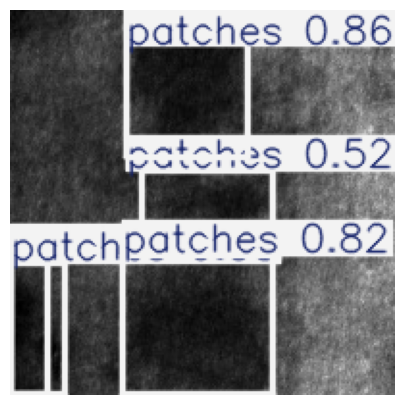


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/1 /content/neu_yolo/images/test/pitted_surface_16.jpg: 224x224 1 pitted_surface, 100.2ms
Speed: 1.9ms preprocess, 100.2ms inference, 3.3ms postprocess per image at shape (1, 3, 224, 224)


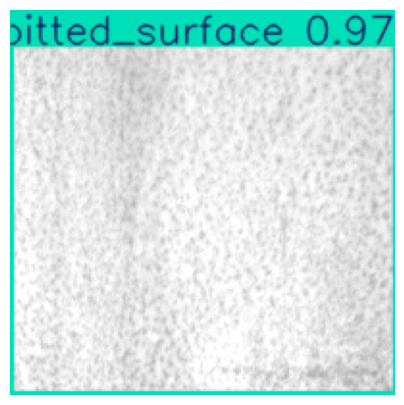


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/1 /content/neu_yolo/images/test/scratches_287.jpg: 224x224 1 scratches, 99.6ms
Speed: 0.9ms preprocess, 99.6ms inference, 1.2ms postprocess per image at shape (1, 3, 224, 224)


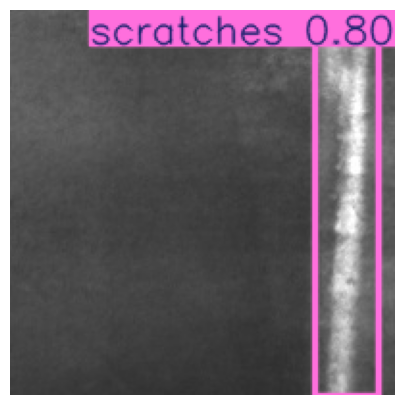


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/1 /content/neu_yolo/images/test/inclusion_154.jpg: 224x224 5 inclusions, 161.9ms
Speed: 2.0ms preprocess, 161.9ms inference, 1.2ms postprocess per image at shape (1, 3, 224, 224)


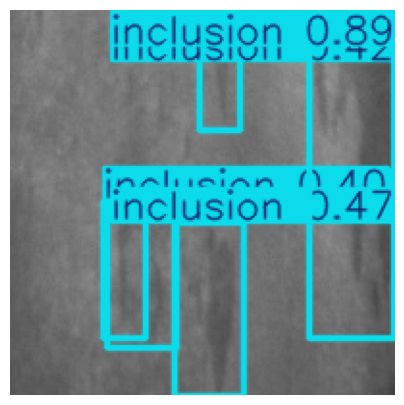


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/1 /content/neu_yolo/images/test/pitted_surface_299.jpg: 224x224 3 pitted_surfaces, 68.2ms
Speed: 1.3ms preprocess, 68.2ms inference, 1.1ms postprocess per image at shape (1, 3, 224, 224)


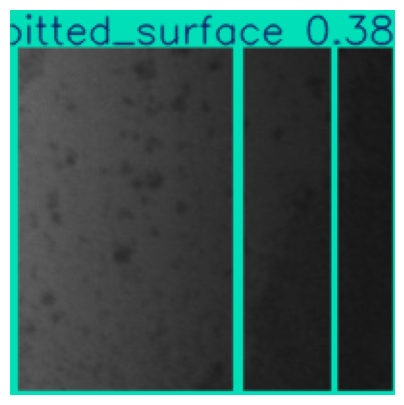

In [ ]:
test_images = list((YOLO_ROOT / "images" / "test").glob("*.jpg"))[:5]

for img_path in test_images:
    results = model.predict(
        source=str(img_path),
        imgsz=200,
        conf=0.25
    )

    plotted = results[0].plot()
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [ ]:
print(metrics.box.map)
print(metrics.box.map50)
print(metrics.box.mp)
print(metrics.box.mr)

0.44329314486667337
0.7524075165602664
0.6975414564942947
0.7181493387882223


#11) Save results

In [ ]:
results_summary = {
    "model": "YOLOv8n",
    "mAP50": metrics.box.map50,
    "mAP50_95": metrics.box.map,
    "precision": metrics.box.mp,
    "recall": metrics.box.mr
}

results_summary

{'model': 'YOLOv8n',
 'mAP50': np.float64(0.7524075165602664),
 'mAP50_95': np.float64(0.44329314486667337),
 'precision': np.float64(0.6975414564942947),
 'recall': np.float64(0.7181493387882223)}

In [ ]:
output_dir = "/content/yolo_predictions"

results = model.predict(
    source=str(YOLO_ROOT / "images" / "test"),
    imgsz=200,
    conf=0.25,
    save=True,
    project=output_dir,
    name="predictions"
)


WARNING ⚠️ imgsz=[200] must be multiple of max stride 32, updating to [224]
image 1/270 /content/neu_yolo/images/test/crazing_104.jpg: 224x224 1 crazing, 45.6ms
image 2/270 /content/neu_yolo/images/test/crazing_114.jpg: 224x224 (no detections), 44.1ms
image 3/270 /content/neu_yolo/images/test/crazing_126.jpg: 224x224 1 crazing, 37.9ms
image 4/270 /content/neu_yolo/images/test/crazing_132.jpg: 224x224 2 crazings, 85.2ms
image 5/270 /content/neu_yolo/images/test/crazing_143.jpg: 224x224 1 crazing, 100.7ms
image 6/270 /content/neu_yolo/images/test/crazing_154.jpg: 224x224 1 crazing, 64.4ms
image 7/270 /content/neu_yolo/images/test/crazing_162.jpg: 224x224 (no detections), 75.8ms
image 8/270 /content/neu_yolo/images/test/crazing_169.jpg: 224x224 3 crazings, 61.7ms
image 9/270 /content/neu_yolo/images/test/crazing_179.jpg: 224x224 3 crazings, 62.7ms
image 10/270 /content/neu_yolo/images/test/crazing_180.jpg: 224x224 1 crazing, 73.2ms
image 11/270 /content/neu_yolo/images/test/crazing_185.j

In [ ]:
import shutil

shutil.copy(
    "/content/runs/neu_yolov8n/weights/best.pt",
    "/content/yolov8n_neu_defect_best.pt"
)

'/content/yolov8n_neu_defect_best.pt'

In [ ]:
!ls /content/yolov8n_neu_defect_best.pt

/content/yolov8n_neu_defect_best.pt


In [ ]:
!ls -lh /content/yolov8n_neu_defect_best.pt

-rw-r--r-- 1 root root 6.0M Jun  5 16:39 /content/yolov8n_neu_defect_best.pt


In [ ]:
from google.colab import files
files.download("/content/yolov8n_neu_defect_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!find /content/yolo_predictions -type f | head

/content/yolo_predictions/predictions/patches_207.jpg
/content/yolo_predictions/predictions/pitted_surface_16.jpg
/content/yolo_predictions/predictions/scratches_287.jpg
/content/yolo_predictions/predictions/inclusion_154.jpg
/content/yolo_predictions/predictions/pitted_surface_299.jpg
/content/yolo_predictions/predictions/rolled-in_scale_219.jpg
/content/yolo_predictions/predictions/scratches_190.jpg
/content/yolo_predictions/predictions/pitted_surface_119.jpg
/content/yolo_predictions/predictions/patches_132.jpg
/content/yolo_predictions/predictions/inclusion_282.jpg


In [ ]:
!zip -r yolo_predictions.zip /content/yolo_predictions

  adding: content/yolo_predictions/ (stored 0%)
  adding: content/yolo_predictions/predictions/ (stored 0%)
  adding: content/yolo_predictions/predictions/patches_207.jpg (deflated 1%)
  adding: content/yolo_predictions/predictions/pitted_surface_16.jpg (deflated 2%)
  adding: content/yolo_predictions/predictions/scratches_287.jpg (deflated 4%)
  adding: content/yolo_predictions/predictions/inclusion_154.jpg (deflated 2%)
  adding: content/yolo_predictions/predictions/pitted_surface_299.jpg (deflated 5%)
  adding: content/yolo_predictions/predictions/rolled-in_scale_219.jpg (deflated 1%)
  adding: content/yolo_predictions/predictions/scratches_190.jpg (deflated 3%)
  adding: content/yolo_predictions/predictions/pitted_surface_119.jpg (deflated 3%)
  adding: content/yolo_predictions/predictions/patches_132.jpg (deflated 1%)
  adding: content/yolo_predictions/predictions/inclusion_282.jpg (deflated 3%)
  adding: content/yolo_predictions/predictions/crazing_126.jpg (deflated 1%)
  adding:

In [ ]:
from google.colab import files
files.download("yolo_predictions.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>